# Plot 1: Phase Plots

In [144]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams["text.usetex"] = False
plt.rcParams["font.size"] = 12
#plt.rcParams["font.family"] = 'lmodern'
plt.rcParams["font.family"] = 'Arial'

hole_color = "#FF3939"
hole_alpha = 0.3

single_color = "#ade9a3"
single_alpha = 0.4

double_color = "#bce6f8"
double_alpha = 0.5

def plot_band(ax, xarray, yarray, phase_lower, phase_higher,
              arrow=False, arrow_pos=0, hatch='', double=False):
    # Main curve
    ax.plot(xarray, yarray, color="black", linewidth=1, label=r'$\epsilon_k$')

    # Fills
    ax.fill_between(
        xarray, np.clip(yarray, phase_higher, 1), 1,
        facecolor=hole_color, alpha=hole_alpha,
        hatch=hatch, edgecolor="gray", linewidth=0.0,
        label="Empty"
    )
    ax.fill_between(
        xarray, np.clip(yarray, phase_lower, phase_higher), phase_higher,
        alpha=single_alpha, color=single_color,
        where=(yarray <= phase_higher),
        label="Singly Occupied"
    )
    ax.fill_between(
        xarray, np.clip(yarray, -1, phase_lower), phase_lower,
        alpha=double_alpha, color=double_color,
        where=(yarray <= phase_lower),
        label="Doubly Occupied"
    )

    # Horizontal dashed lines
    if phase_higher != 1:
        ax.hlines(phase_higher, -np.arccos(-phase_higher), np.arccos(-phase_higher),
                colors="black", linestyles="dashed", linewidth=1)

    if phase_higher != 0:
        ax.hlines(phase_lower, -np.arccos(-phase_lower), np.arccos(-phase_lower),
                colors="black", linestyles="dashed", linewidth=1)

    # Optional arrow
    if arrow:
        ax.annotate(
            '', xy=(arrow_pos, phase_higher), xycoords='data',
            xytext=(arrow_pos, phase_lower), textcoords='data',
            arrowprops=dict(arrowstyle='<->', color='black', linewidth=1)
        )
        ax.text(arrow_pos + 0.1, (phase_lower + phase_higher)/2,
                r"$U$", va="center", ha="left")
        
        ax.annotate(
            '', xy=(-np.pi + 1, 1.03), xycoords='data',
            xytext=(-np.pi + 1, -1.03), textcoords='data',
            arrowprops=dict(arrowstyle='<->', color='black', linewidth=1)
        )
        ax.text(-np.pi + 0.5, 0.3,
                r"$W$", va="center", ha="left")
        
    if double == True:
        ax.text(np.arccos(-phase_lower) + 0.1, phase_lower - 0.05,
                r'$\epsilon_{k_F}$', va="center", ha="left")
    else:
        if phase_lower != -1:    
            ax.text(np.arccos(-phase_lower) + 0.1, phase_lower,
                    r'$\epsilon_{D}$', va="center", ha="left")
        if phase_higher != 1:
            ax.text(np.arccos(-phase_higher) + 0.1, phase_higher,
                    r'$\epsilon_{S}$', va="center", ha="left")
        

    # Clean up axes
    # Axes styling: x-axis through zero, no y-axis
    ax.spines["bottom"].set_position("zero")
    ax.spines["bottom"].set_color("black")
    ax.spines["bottom"].set_linewidth(1)

    ax.spines["left"].set_position("zero")
    ax.spines["left"].set_color("black")
    ax.spines["left"].set_linewidth(1)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.set_xticks([-np.pi, np.pi])
    ax.set_xticklabels([r"$-\pi$", r"$\pi$"])
    ax.set_yticks([])

    ax.set_ylim(-1.1, 1.2)
    
    # ---- ADD AXIS ARROWHEADS ----
    ax.plot(1, 0, ">k", transform=ax.get_yaxis_transform(), clip_on=False)
    ax.plot(0, 1, "^k", transform=ax.get_xaxis_transform(), clip_on=False)
    
    
    # Axis labels
    ax.text(np.pi + 0.5, 0, r"$k$", va="center", ha="left")
    ax.text(0, 1.35, r"$\epsilon_k$", ha="center")



def plot_occupation_numbers(ax, k0, k1, klabels=False, double=False):
    k0 *= np.pi
    k1 *= np.pi
    x = np.linspace(-np.pi, np.pi, 5000)

    # Axes styling: x-axis through zero, no y-axis
    ax.spines["bottom"].set_position("zero")
    ax.spines["bottom"].set_color("black")
    ax.spines["bottom"].set_linewidth(1)

    ax.spines["left"].set_position("zero")
    ax.spines["left"].set_color("black")
    ax.spines["left"].set_linewidth(1)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    f = np.piecewise(
        x,
        [np.abs(x) < k0, (np.abs(x) >= k0) & (np.abs(x) < k1), np.abs(x) >= k1],
        [2, 1, 0]
    )

    line, = ax.plot(x, f, color="black", linewidth=1, label=r'$n_k$', zorder=2)

    # Fills
    mask = (x >= -k0) & (x <= k0)
    ax.fill_between(x[mask], 0, 2,
                    alpha=double_alpha, color=double_color, label="Doubly Occupied")
    ax.fill_between(x, 0, 1,
                    alpha=single_alpha, color=single_color, where=(f == 1),
                    label="Singly Occupied")
    ax.fill_between(x, 0.1, 0,
                    alpha=hole_alpha, color=hole_color, where=(f == 0),
                    label="Empty")

    if klabels == True:
    # Axis ticks/labels:
        ax.set_xticks([-np.pi, -k1, -k0, 0, k0, k1, np.pi])
        ax.set_xticklabels([r"$-\pi$", r"$-k_S$", r"$-k_D$", 0,
                            r"$k_D$", r"$k_S$", r"$\pi$"])
        ax.set_yticks([1])
        ax.text(-0.2, 2.1, "2", ha="right", va="center",
                zorder=10, clip_on=False, transform=ax.transData)
        
        ax.vlines((-k0, k0), 0, 1, 'black', linestyles='dashed', linewidth=1)        
    else:
        if k1 == np.pi:
            if k0 != 0:
                ax.set_yticks([1])
                ax.text(-0.2, 2.1, "2", ha="right", va="center",
                    zorder=10, clip_on=False, transform=ax.transData)
                ax.vlines((-k0, k0), 0, 1, 'black', linestyles='dashed', linewidth=1)
                ax.set_xticks([-np.pi,-k0, 0, k0, np.pi])
                ax.set_xticklabels([r"$-\pi$", r"$-k_D$", 0, r"$k_D$", r"$\pi$"])
            else:
                ax.set_yticks([2])
                ax.text(-0.2, 1.1, "1", ha="right", va="center",
                        zorder=10, clip_on=False, transform=ax.transData)
                ax.set_xticks([-np.pi, 0, np.pi])
                ax.set_xticklabels([r"$-\pi$", 0, r"$\pi$"])
        else:
            if k0 == 0:
                ax.set_xticks([-np.pi,-k1, 0, k1, np.pi])
                ax.set_xticklabels([r"$-\pi$", r"$-k_S$", 0, r"$k_S$", r"$\pi$"])
                ax.set_yticks([2])
                ax.text(-0.2, 1.1, "1", ha="right", va="center",
                    zorder=10, clip_on=False, transform=ax.transData)
            else:
                ax.set_yticks([1])
                ax.text(-0.2, 2.1, "2", ha="right", va="center",
                    zorder=10, clip_on=False, transform=ax.transData)
                if k1 != k0:
                    ax.vlines((-k0, k0), 0, 1, 'black', linestyles='dashed', linewidth=1)
                    ax.set_xticks([-np.pi,-k0, 0, k0, np.pi])
                    ax.set_xticklabels([r"$-\pi$", r"$-k_D$", 0, r"$k_D$", r"$\pi$"])

    if double == True:
        ax.set_yticks([1])
        ax.text(-0.2, 2.1, "2", ha="right", va="center",
                zorder=10, clip_on=False, transform=ax.transData)
        ax.set_xticks([-np.pi,-k1, 0, k1, np.pi])
        ax.set_xticklabels([r"$-\pi$", r"$-k_F$", 0, r"$k_F$", r"$\pi$"])


    # --- PLOT LIMITS ---
    ax.set_xlim(-np.pi - 0.2, np.pi + 0.4)
    ax.set_ylim(0, 2.2)

    # --- AXIS LABLES ---
    ax.text(0, 2.35, r"$n_k$", ha="center")
    ax.text(np.pi + 0.5, 0, r"$k$", va="center")

    # --- AXIS ARROWS ---
    ax.plot(1, 0, ">k", transform=ax.get_yaxis_transform(), clip_on=False)
    ax.plot(0, 1, "^k", transform=ax.get_xaxis_transform(), clip_on=False)



k = np.linspace(-np.pi, np.pi, 1000)
eps_k = -np.cos(k)



In [142]:
# 1. Create the grid (4 rows, 2 columns)
# figsize=(width, height) - adjust this to make it look less cramped
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(8, 10))

# 2. Flatten the axes array for easy iteration
# 'axes' is a 2D array (4x2), flattening it makes it 1D (length 8)
axes_flat = axes.flatten()

# 3. Loop through and plot your data
plot_band(axes_flat[0], k, eps_k, -0.3, 0.5, arrow=True, arrow_pos=0.8)
plot_band(axes_flat[2], k, eps_k, -1, 0.3, arrow=False, arrow_pos=0.8)
plot_band(axes_flat[4], k, eps_k, 0.3, 1, arrow=False, arrow_pos=0.8)
plot_band(axes_flat[6], k, eps_k, -1, 1, arrow=False, arrow_pos=0.8)

plot_occupation_numbers(axes_flat[1], 0.25, 0.7, klabels=True)
plot_occupation_numbers(axes_flat[3], 0, 0.7)
plot_occupation_numbers(axes_flat[5], 0.5, 1)
plot_occupation_numbers(axes_flat[7], 0, 1)

axes_flat[0].text(-0.5, 0.7, r"$H$")
axes_flat[0].text(-0.5, 0.1, r"$S$")
axes_flat[0].text(-0.5, -0.65, r"$D$")

axes_flat[2].text(-0.5, 0.6, r"$H$")
axes_flat[2].text(-0.5, -0.3, r"$S$")

axes_flat[4].text(-0.5, 0.6, r"$S$")
axes_flat[4].text(-0.5, -0.3, r"$D$")

axes_flat[6].text(-0.5, 0.3, r"$S$")




# 4. Critical step: Use tight_layout to prevent overlapping labels
plt.tight_layout()
plt.show()

RuntimeError: latex was not able to process the following string:
b'lp'

Here is the full command invocation and its output:

latex -interaction=nonstopmode --halt-on-error --output-directory=tmpu6t86d1g 37fe1867bb9c0161e8b349683bc85f5a.tex

This is pdfTeX, Version 3.14159265-2.6-1.40.19 (TeX Live 2018) (preloaded format=latex)
 restricted \write18 enabled.
entering extended mode
(./37fe1867bb9c0161e8b349683bc85f5a.tex
LaTeX2e <2018-04-01> patch level 2
Babel <3.18> and hyphenation patterns for 22 language(s) loaded.
(/usr/local/texlive/2018basic/texmf-dist/tex/latex/base/article.cls
Document Class: article 2014/09/29 v1.4h Standard LaTeX document class
(/usr/local/texlive/2018basic/texmf-dist/tex/latex/base/size10.clo))

! LaTeX Error: File `type1cm.sty' not found.

Type X to quit or <RETURN> to proceed,
or enter new name. (Default extension: sty)

Enter file name: 
! Emergency stop.
<read *> 
         
l.7 \usepackage
               {type1ec}^^M
No pages of output.
Transcript written

Error in callback <function _draw_all_if_interactive at 0x10de58180> (for post_execute), with arguments args (),kwargs {}:


RuntimeError: latex was not able to process the following string:
b'lp'

Here is the full command invocation and its output:

latex -interaction=nonstopmode --halt-on-error --output-directory=tmp_kty6xea 37fe1867bb9c0161e8b349683bc85f5a.tex

This is pdfTeX, Version 3.14159265-2.6-1.40.19 (TeX Live 2018) (preloaded format=latex)
 restricted \write18 enabled.
entering extended mode
(./37fe1867bb9c0161e8b349683bc85f5a.tex
LaTeX2e <2018-04-01> patch level 2
Babel <3.18> and hyphenation patterns for 22 language(s) loaded.
(/usr/local/texlive/2018basic/texmf-dist/tex/latex/base/article.cls
Document Class: article 2014/09/29 v1.4h Standard LaTeX document class
(/usr/local/texlive/2018basic/texmf-dist/tex/latex/base/size10.clo))

! LaTeX Error: File `type1cm.sty' not found.

Type X to quit or <RETURN> to proceed,
or enter new name. (Default extension: sty)

Enter file name: 
! Emergency stop.
<read *> 
         
l.7 \usepackage
               {type1ec}^^M
No pages of output.
Transcript written

RuntimeError: latex was not able to process the following string:
b'lp'

Here is the full command invocation and its output:

latex -interaction=nonstopmode --halt-on-error --output-directory=tmp9gi0hd3w 37fe1867bb9c0161e8b349683bc85f5a.tex

This is pdfTeX, Version 3.14159265-2.6-1.40.19 (TeX Live 2018) (preloaded format=latex)
 restricted \write18 enabled.
entering extended mode
(./37fe1867bb9c0161e8b349683bc85f5a.tex
LaTeX2e <2018-04-01> patch level 2
Babel <3.18> and hyphenation patterns for 22 language(s) loaded.
(/usr/local/texlive/2018basic/texmf-dist/tex/latex/base/article.cls
Document Class: article 2014/09/29 v1.4h Standard LaTeX document class
(/usr/local/texlive/2018basic/texmf-dist/tex/latex/base/size10.clo))

! LaTeX Error: File `type1cm.sty' not found.

Type X to quit or <RETURN> to proceed,
or enter new name. (Default extension: sty)

Enter file name: 
! Emergency stop.
<read *> 
         
l.7 \usepackage
               {type1ec}^^M
No pages of output.
Transcript written

<Figure size 800x1000 with 8 Axes>

## Alternative: Box Plot

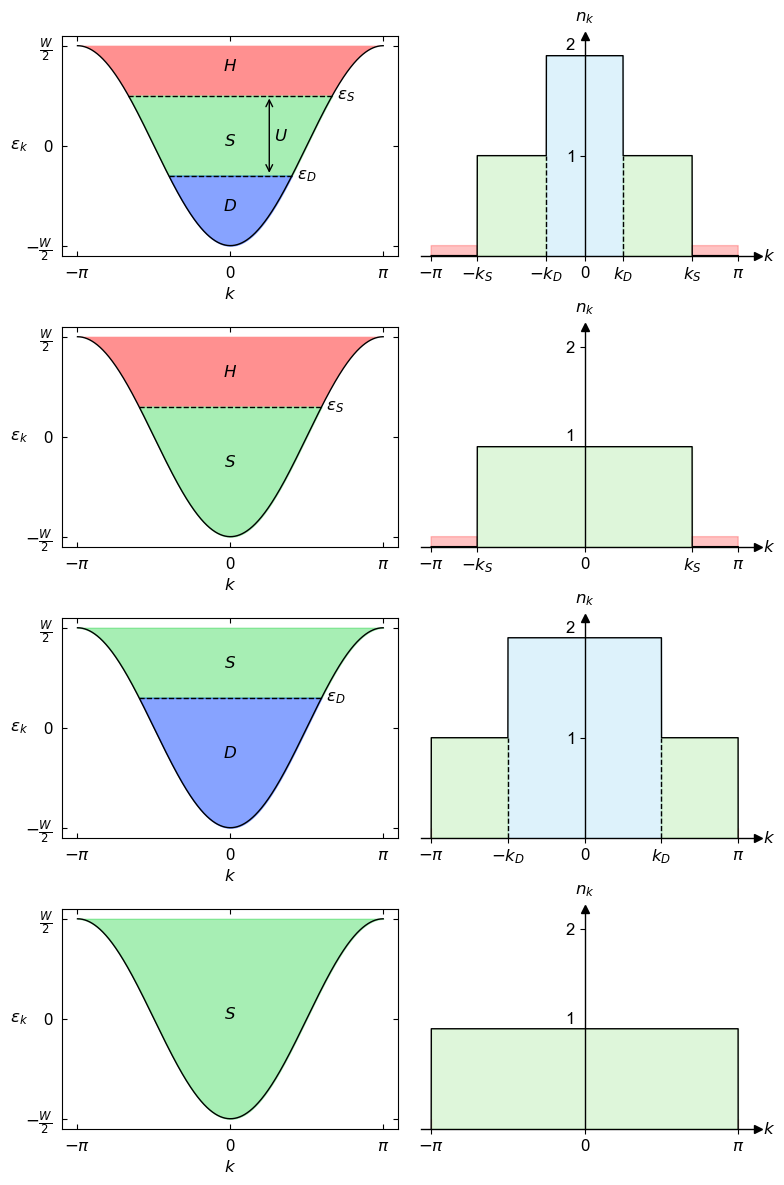

In [35]:

def plot_band_box(ax, xarray, yarray, phase_lower, phase_higher,
              arrow=False, arrow_pos=0, hatch='', double=False, labels=True):
    # Main curve
    ax.plot(xarray, yarray, color="black", linewidth=1, label=r'$\epsilon_k$')

    # Fills
    ax.fill_between(
        xarray, np.clip(yarray, phase_higher, 1), 1,
        facecolor="#ff2222", alpha=0.5,
        hatch=hatch, edgecolor="gray", linewidth=0.0,
        label="Empty"
    )
    ax.fill_between(
        xarray, np.clip(yarray, phase_lower, phase_higher), phase_higher,
        alpha=0.4, color="#23d544",
        where=(yarray <= phase_higher),
        label="Singly Occupied"
    )
    ax.fill_between(
        xarray, np.clip(yarray, -1, phase_lower), phase_lower,
        alpha=0.5, color="#1048ff",
        where=(yarray <= phase_lower),
        label="Doubly Occupied"
    )

    # Horizontal dashed lines
    if phase_higher != 1:
        ax.hlines(phase_higher, -np.arccos(-phase_higher), np.arccos(-phase_higher),
                colors="black", linestyles="dashed", linewidth=1)

    if phase_higher != 0:
        ax.hlines(phase_lower, -np.arccos(-phase_lower), np.arccos(-phase_lower),
                colors="black", linestyles="dashed", linewidth=1)

    # Optional arrow
    if arrow:
        ax.annotate(
            '', xy=(arrow_pos, phase_higher), xycoords='data',
            xytext=(arrow_pos, phase_lower), textcoords='data',
            arrowprops=dict(arrowstyle='<->', color='black', linewidth=1)
        )
        ax.text(arrow_pos + 0.1, (phase_lower + phase_higher)/2,
                r"$U$", va="center", ha="left")
        

    if labels:    
        if double == True:
            ax.text(np.arccos(-phase_lower) + 0.1, phase_lower - 0.05,
                    r'$\epsilon_{k_F}$', va="center", ha="left")
        else:
            if phase_lower != -1:    
                ax.text(np.arccos(-phase_lower) + 0.1, phase_lower,
                        r'$\epsilon_{D}$', va="center", ha="left")
            if phase_higher != 1:
                ax.text(np.arccos(-phase_higher) + 0.1, phase_higher,
                        r'$\epsilon_{S}$', va="center", ha="left")
            

    # Clean up axes
    # Axes styling: x-axis through zero, no y-axis
    #ax.spines["bottom"].set_position("zero")
    ax.spines["bottom"].set_color("black")
    #ax.spines["bottom"].set_linewidth(1)

    #ax.spines["left"].set_position("zero")
    ax.spines["left"].set_color("black")
    #ax.spines["left"].set_linewidth(1)

    ax.spines["top"].set_visible(True)
    ax.spines["right"].set_visible(True)

    ax.tick_params(top=True, right=True, direction='in', pad=7)

    if labels:
        ax.set_xticks([-np.pi, 0, np.pi])
        ax.set_xticklabels([r"$-\pi$", 0, r"$\pi$"])
        ax.set_yticks([-1, 0, 1])
        ax.set_yticklabels([r"$-\frac{W}{2}$", 0, r"$\frac{W}{2}$"])

        ax.set_xlabel(r"$k$")
        ax.set_ylabel(r"$\epsilon_k$", rotation='horizontal', ha="center", va="center")

    


# 1. Create the grid (4 rows, 2 columns)
# figsize=(width, height) - adjust this to make it look less cramped
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(8, 12))

# 2. Flatten the axes array for easy iteration
# 'axes' is a 2D array (4x2), flattening it makes it 1D (length 8)
axes_flat = axes.flatten()

# 3. Loop through and plot your data
plot_band_box(axes_flat[0], k, eps_k, -0.3, 0.5, arrow=True, arrow_pos=0.8)
plot_band_box(axes_flat[2], k, eps_k, -1, 0.3, arrow=False, arrow_pos=0.8)
plot_band_box(axes_flat[4], k, eps_k, 0.3, 1, arrow=False, arrow_pos=0.8)
plot_band_box(axes_flat[6], k, eps_k, -1, 1, arrow=False, arrow_pos=0.8)

plot_occupation_numbers(axes_flat[1], 0.25, 0.7, klabels=True)
plot_occupation_numbers(axes_flat[3], 0, 0.7)
plot_occupation_numbers(axes_flat[5], 0.5, 1)
plot_occupation_numbers(axes_flat[7], 0, 1)

axes_flat[0].text(0, 0.75, r"$H$", ha="center")
axes_flat[0].text(0, 0, r"$S$", ha="center")
axes_flat[0].text(0, -0.65, r"$D$", ha="center")

axes_flat[2].text(0, 0.6, r"$H$", ha="center")
axes_flat[2].text(0, -0.3, r"$S$", ha="center")

axes_flat[4].text(0, 0.6, r"$S$", ha="center")
axes_flat[4].text(0, -0.3, r"$D$", ha="center")

axes_flat[6].text(0, 0, r"$S$", ha="center")

plt.tight_layout()
plt.show()


# Dimensionless Phase Diagram

Canvas size (set)     : 4.252 in x 3.280 in = 10.80 cm x 8.33 cm
Tight bbox (rendered)  : 3.79535 in x 3.05845 in = 9.64018 cm x 7.76846 cm


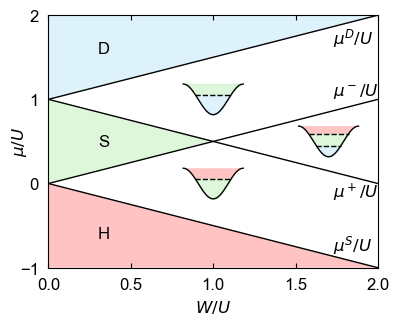

In [152]:
from matplotlib.ticker import MultipleLocator

def plot_band_box(ax, xarray, yarray, phase_lower, phase_higher,
              arrow=False, arrow_pos=0, hatch='', double=False, labels=True):
    # Main curve
    ax.plot(xarray, yarray, color="black", linewidth=1, label=r'$\epsilon_k$')

    # Fills
    ax.fill_between(
        xarray, np.clip(yarray, phase_higher, 1), 1,
        facecolor=hole_color, alpha=hole_alpha,
        hatch=hatch, edgecolor="gray", linewidth=0.0,
        label="Empty"
    )
    ax.fill_between(
        xarray, np.clip(yarray, phase_lower, phase_higher), phase_higher,
        alpha=single_alpha, color=single_color,
        where=(yarray <= phase_higher),
        label="Singly Occupied"
    )
    ax.fill_between(
        xarray, np.clip(yarray, -1, phase_lower), phase_lower,
        alpha=double_alpha, color=double_color,
        where=(yarray <= phase_lower),
        label="Doubly Occupied"
    )

    # Horizontal dashed lines
    if not(phase_higher == 1 and phase_lower == 1):
        if phase_higher != 1:
            ax.hlines(phase_higher, -np.arccos(-phase_higher), np.arccos(-phase_higher),
                    colors="black", linestyles="dashed", linewidth=1)

        if phase_higher != 0:
            ax.hlines(phase_lower, -np.arccos(-phase_lower), np.arccos(-phase_lower),
                    colors="black", linestyles="dashed", linewidth=1)

    # Optional arrow
    if arrow:
        ax.annotate(
            '', xy=(arrow_pos, phase_higher), xycoords='data',
            xytext=(arrow_pos, phase_lower), textcoords='data',
            arrowprops=dict(arrowstyle='<->', color='black', linewidth=1)
        )
        ax.text(arrow_pos + 0.1, (phase_lower + phase_higher)/2,
                r"$U$", va="center", ha="left")
        

    if labels:    
        if double == True:
            ax.text(np.arccos(-phase_lower) + 0.1, phase_lower - 0.05,
                    r'$\epsilon_{k_F}$', va="center", ha="left")
        else:
            if phase_lower != -1:    
                ax.text(np.arccos(-phase_lower) + 0.1, phase_lower,
                        r'$\epsilon_{D}$', va="center", ha="left")
            if phase_higher != 1:
                ax.text(np.arccos(-phase_higher) + 0.1, phase_higher,
                        r'$\epsilon_{S}$', va="center", ha="left")
            

    # Clean up axes
    # Axes styling: x-axis through zero, no y-axis
    #ax.spines["bottom"].set_position("zero")
    ax.spines["bottom"].set_color("black")
    #ax.spines["bottom"].set_linewidth(1)

    #ax.spines["left"].set_position("zero")
    ax.spines["left"].set_color("black")
    #ax.spines["left"].set_linewidth(1)

    ax.spines["top"].set_visible(True)
    ax.spines["right"].set_visible(True)

    ax.tick_params(top=True, right=True, direction='in', pad=7)

    if labels:
        ax.set_xticks([-np.pi, 0, np.pi])
        ax.set_xticklabels([r"$-\pi$", 0, r"$\pi$"])
        ax.set_yticks([-1, 0, 1])
        ax.set_yticklabels([r"$-\frac{W}{2}$", 0, r"$\frac{W}{2}$"])

        ax.set_xlabel(r"$k$")
        ax.set_ylabel(r"$\epsilon_k$", rotation='horizontal', ha="center", va="center")

def plot_2nd_pd(y_max, save_title=''):
    # Create the plot
    fig, ax = plt.subplots()

    fig.set_size_inches(6.377953 / 1.5, 2.73341 * 1.2)

    x1 = np.linspace(0, 2, 500)

    muplus = 1 - x1 / 2
    muminus = x1 / 2

    muE = -x1 / 2
    muF = 1 + x1 / 2

    ax.plot(x1, muplus, color='black', linewidth=1)
    ax.plot(x1, muminus, color='black', linewidth=1)
    ax.plot(x1, muE, color='black', linewidth=1)
    ax.plot(x1, muF, color='black', linewidth=1)

    ax.text(0.3, 0.5, 'S', ha='left', va='center')

    ax.text(0.3, 1.6, 'D', ha='left', va='center')
    ax.text(0.3, -0.6, 'H', ha='left', va='center')

    ax.text(1.73, 1.73, r'$\mu^D/U$', ha='left', va='center')
    ax.text(1.73, 1.10, r'$\mu^-/U$', ha='left', va='center')
    ax.text(1.73, -0.10, r'$\mu^+/U$', ha='left', va='center')
    ax.text(1.73, -0.73, r'$\mu^S/U$', ha='left', va='center')

    ax.fill_between(x1, muminus, muplus, where=(muplus > muminus),
                    facecolor=single_color, alpha=single_alpha, label='Insulating')
    ax.fill_between(x1, muF, 2, facecolor=double_color, alpha=double_alpha)
    ax.fill_between(x1, -1, muE, facecolor=hole_color, alpha=hole_alpha)

    # Labels and legend
    ax.set_xlabel(r'$W/U$')
    ax.set_ylabel(r'$\mu / U$', va='top', labelpad=7)

    ax.set_xlim(0, 2)
    ax.set_ylim(1 - y_max, y_max)
    ax.tick_params(top=True, right=False, left=False, direction='in', pad=7)

    # Set major tick intervals
    ax.xaxis.set_major_locator(MultipleLocator(0.5))
    ax.yaxis.set_major_locator(MultipleLocator(1))

    # --- Inset 1: Region SD ---
    ax_ins1 = ax.inset_axes([0.8, 0.8, 0.4, 0.4], transform=ax.transData)
    plot_band_box(ax_ins1, k, eps_k, 0.3, 1, labels=False)

    # --- Inset 2: Region HS ---
    ax_ins2 = ax.inset_axes([0.8, -0.2, 0.4, 0.4], transform=ax.transData)
    plot_band_box(ax_ins2, k, eps_k, -1, 0.3, labels=False)

    # --- Inset 3 ---
    ax_ins3 = ax.inset_axes([1.5, 0.3, 0.4, 0.4], transform=ax.transData)
    plot_band_box(ax_ins3, k, eps_k, -0.3, 0.5, labels=False)

    # Clean up insets
    for a in [ax_ins1, ax_ins2, ax_ins3]:
        a.set_xticks([])
        a.set_yticks([])
        a.spines["top"].set_visible(False)
        a.spines["right"].set_visible(False)
        a.spines["left"].set_visible(False)
        a.spines["bottom"].set_visible(False)

    if save_title != '':
        plt.savefig(save_title, dpi=1000, bbox_inches="tight")

    # --- after you finish building the figure ---
    fig.canvas.draw()
    renderer = fig.canvas.get_renderer()

    # 1) Canvas nominal size
    canvas_w_in, canvas_h_in = fig.get_size_inches()
    print(f"Canvas size (set)     : {canvas_w_in:.3f} in x {canvas_h_in:.3f} in "
          f"= {canvas_w_in*2.54:.2f} cm x {canvas_h_in*2.54:.2f} cm")

    # 2) Tight bounding box
    tight_bbox = fig.get_tightbbox(renderer)
    tight_w_in = tight_bbox.width
    tight_h_in = tight_bbox.height
    print(f"Tight bbox (rendered)  : {tight_w_in:.5f} in x {tight_h_in:.5f} in "
          f"= {tight_w_in*2.54:.5f} cm x {tight_h_in*2.54:.5f} cm")

    plt.show()


plot_2nd_pd(2)

# 1D Phase Diagram

<>:101: SyntaxWarning: invalid escape sequence '\ '
<>:101: SyntaxWarning: invalid escape sequence '\ '
/var/folders/6g/kfvfxvvs2473z8z47g0kr34w0000gn/T/ipykernel_897/2548864102.py:101: SyntaxWarning: invalid escape sequence '\ '
  hatch='\ ', hatch_linewidth=5, edgecolor=double_color)
/var/folders/6g/kfvfxvvs2473z8z47g0kr34w0000gn/T/ipykernel_897/2548864102.py:100: MatplotlibDeprecationWarning: hatch must consist of a string of "*+-./OX\ox|" or None, but found the following invalid values " ". Passing invalid values is deprecated since 3.4 and will become an error in 3.11.
  ax.fill_between([2, 2.41], -0.65, 2, facecolor='none', alpha=double_alpha,


0.8


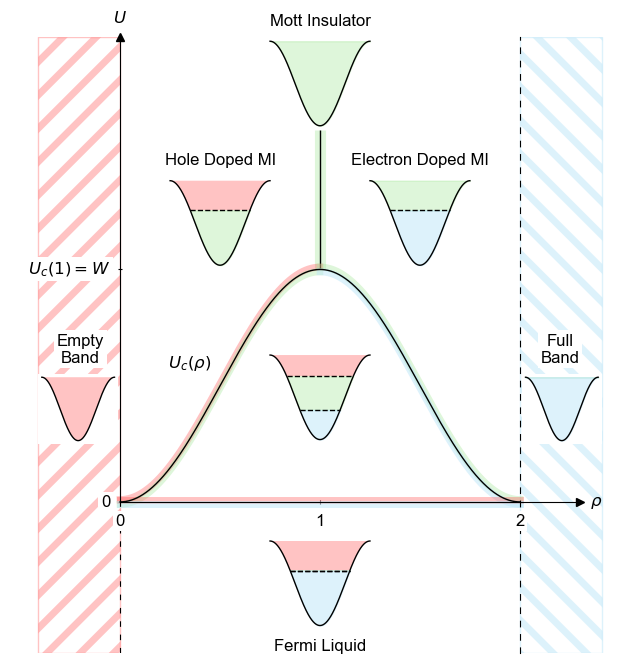

In [151]:
def plot_pd(rho: np.array, U_c_norm: np.array, offset=0.05, label_pos=-0.05, width_inserts=0.4, height_inserts=0.4, save_title=''):
    # Create the plot
    fig, ax = plt.subplots(figsize=(8,8))

    # fig.set_size_inches(6.377953 / 1.5, 2.73341 * 1.2)

    ax.vlines(x=1, ymin=1, ymax=1.6, color=single_color, alpha=single_alpha, linestyle='-', linewidth=8)
    ax.vlines(x=1, ymin=1, ymax=1.6, color='black', linestyle='-', linewidth=1)

    N = len(rho)

    # --- All lines ---
    
    x_1 = rho[:int(N/2)]
    x_2 = rho[int(N/2):]
    y_1 = U_c_norm[:int(N/2)]
    y_2 = U_c_norm[int(N/2):]

    ax.plot(x_1, y_1+0.01, color=hole_color, alpha=hole_alpha, linewidth=5)
    ax.plot(x_1, y_1-0.01, color=single_color, alpha=single_alpha, linewidth=5)

    ax.plot(x_2, y_2+0.01, color=single_color, alpha=single_alpha, linewidth=5)
    ax.plot(x_2, y_2-0.01, color=double_color, alpha=double_alpha, linewidth=5)

    ax.plot([0, 2], [0.01, 0.01], color=hole_color, alpha=hole_alpha, linewidth=5)
    ax.plot([0, 2], [-0.01, -0.01], color=double_color, alpha=double_alpha, linewidth=5)
    
    """ 
    ax.fill_between(rho, U_c_norm, U_c_norm + offset, where=(rho <= 1), facecolor=hole_color, alpha=hole_alpha)
    ax.fill_between(rho, U_c_norm, U_c_norm - offset, where=(rho <= 1), facecolor=single_color, alpha=single_alpha)

    ax.fill_between(rho, U_c_norm, U_c_norm + offset, where=(rho >= 1), facecolor=single_color, alpha=single_alpha)
    ax.fill_between(rho, U_c_norm, U_c_norm - offset, where=(rho >= 1), facecolor=double_color, alpha=double_alpha)

    ax.fill_between([0,2], 0, offset, facecolor=hole_color, alpha=hole_alpha)
    ax.fill_between([0,2], 0, -offset, facecolor=double_color, alpha=double_alpha)

    """

    ax.plot(rho, U_c_norm, label=r'$U_c (\rho)$', color='black', linewidth=1)


    # --- Spines and Ticks ---

    ax.spines["top"].set_visible(False)

    #ax.set_xlim(0, 2.3)
    ax.set_ylim(-0.65, 2)
    ax.tick_params(top=False, right=False, direction='inout', pad=7)
    # Set major tick intervals
    ax.set_xticks([0, 1, 2])
    ax.set_xticklabels([])

    ax.text(0, label_pos, '0',
        ha='center', va='top',
        bbox=dict(facecolor='white', edgecolor='none', pad=2))
    ax.text(1, label_pos, '1',
        ha='center', va='top',
        bbox=dict(facecolor='white', edgecolor='none', pad=2))
    ax.text(2, label_pos, '2',
        ha='center', va='top',
        bbox=dict(facecolor='white', edgecolor='none', pad=2))
    
    ax.set_yticks([0, 1])
    ax.set_yticklabels([])

    ax.text(label_pos, 0, '0',
        ha='right', va='center',
        bbox=dict(facecolor='white', edgecolor='none', pad=2))
    ax.text(label_pos, 1, r"$U_c(1) = W$",
        ha='right', va='center',
        bbox=dict(facecolor='white', edgecolor='none', pad=2))

    ax.spines["bottom"].set_position("zero")
    ax.spines["bottom"].set_bounds(0, 2.3)
    ax.spines["right"].set_position(("data", 2))
    ax.spines["right"].set_linestyle((0, (5, 7)))
    ax.spines["left"].set_position("zero")
    ax.spines["left"].set_bounds(0, 2)




    # --- AXIS ARROWS ---
    ax.plot(0, 1, "^k", transform=ax.get_xaxis_transform(), clip_on=False)
    ax.plot(2.3, 0, ">k", clip_on=False)



    # --- Hatched Lines and Areas ---

    linewdth = ax.spines["right"].get_linewidth()
    print(linewdth)

    ax.vlines(x=0, ymin=-0.65, ymax=0, linestyle=(0, (5, 7)), color="black", linewidth=linewdth)

    ax.fill_between([-0.41, 0], -0.65, 2, facecolor='none', alpha=hole_alpha,
                    hatch='/', hatch_linewidth=5, edgecolor=hole_color)
    
    ax.fill_between([2, 2.41], -0.65, 2, facecolor='none', alpha=double_alpha,
                    hatch='\ ', hatch_linewidth=5, edgecolor=double_color)


    # --- Inset 1: Region SD  ---
    # [x_pos, y_pos, width_size, height_size]
    ax_ins1 = ax.inset_axes([1.5 - width_inserts/2, 1.0, width_inserts, height_inserts], transform=ax.transData)
    plot_band_box(ax_ins1, k, eps_k, 0.3, 1, labels=False)

    # --- Inset 2: Region HS  ---
    ax_ins2 = ax.inset_axes([0.5 - width_inserts/2, 1.0, width_inserts, height_inserts], transform=ax.transData)
    plot_band_box(ax_ins2, k, eps_k, -1, 0.3, labels=False)

    # --- Inset 2: Region HS  ---
    ax_ins3 = ax.inset_axes([1 - width_inserts/2, 0.25, width_inserts, height_inserts], transform=ax.transData)
    plot_band_box(ax_ins3, k, eps_k, -0.3, 0.5, labels=False)

    ax_ins4 = ax.inset_axes([1 - width_inserts/2, -0.55, width_inserts, height_inserts], transform=ax.transData)
    plot_band_box(ax_ins4, k, eps_k, 0.3, 0.3, labels=False)

    ax_ins5 = ax.inset_axes([1 - width_inserts/2, 1.6, width_inserts, height_inserts], transform=ax.transData)
    plot_band_box(ax_ins5, k, eps_k, -1, 1, labels=False)

    ax_ins6 = ax.inset_axes([2.01, 0.25, 0.4, 0.3], transform=ax.transData)
    plot_band_box(ax_ins6, k, eps_k, 1, 1, labels=False)

    ax_ins7 = ax.inset_axes([-0.41, 0.25, 0.4, 0.3], transform=ax.transData)
    plot_band_box(ax_ins7, k, eps_k, -1, -1, labels=False)

    # Clean up insets (optional)
    for a in [ax_ins1, ax_ins2, ax_ins3, ax_ins4, ax_ins5, ax_ins6, ax_ins7]:
        a.set_xticks([]); a.set_yticks([])
        a.spines["top"].set_visible(False)
        a.spines["right"].set_visible(False)
        a.spines["left"].set_visible(False)
        a.spines["bottom"].set_visible(False)

    # Labels and legend
    ax.text(0, 2.05, r"$U$", ha="center", va="bottom")
    ax.text(2.35, 0, r"$\rho$", va="center", ha="left")

    ax.text(0.35, 0.6, r"$U_c(\rho)$", va="center", ha="center",
            bbox=dict(facecolor='white', edgecolor='none', pad=2))
    ax.text(1, -0.65, "Fermi Liquid", ha="center", va="bottom",
            bbox=dict(facecolor='white', edgecolor='none', pad=2))
    ax.text(0.5, 1.45, "Hole Doped MI", ha="center", 
            bbox=dict(facecolor='white', edgecolor='none', pad=2))
    ax.text(1.5, 1.45, "Electron Doped MI", ha="center",
            bbox=dict(facecolor='white', edgecolor='none', pad=2))
    ax.text(-0.2, 0.6, "Empty\nBand", ha="center",
            bbox=dict(facecolor='white', edgecolor='none', pad=2))
    ax.text(2.2, 0.6, "Full\nBand", ha="center",
            bbox=dict(facecolor='white', edgecolor='none', pad=2))
    ax.text(1, 2.05, "Mott Insulator", ha="center",
            bbox=dict(facecolor='white', edgecolor='none', pad=2))

    if save_title != '':
        plt.savefig(save_title, dpi=1000, bbox_inches="tight")

    plt.show()

rho = np.linspace(0, 2, 1000)
U_c = np.square(np.sin(rho * np.pi /2))

plot_pd(rho, U_c, height_inserts=0.4, width_inserts=0.55, offset=0.05, save_title='Plots/Plots_paper/1d_phase_diagram.pdf')




# Figure 4: Local Magnetic Moment

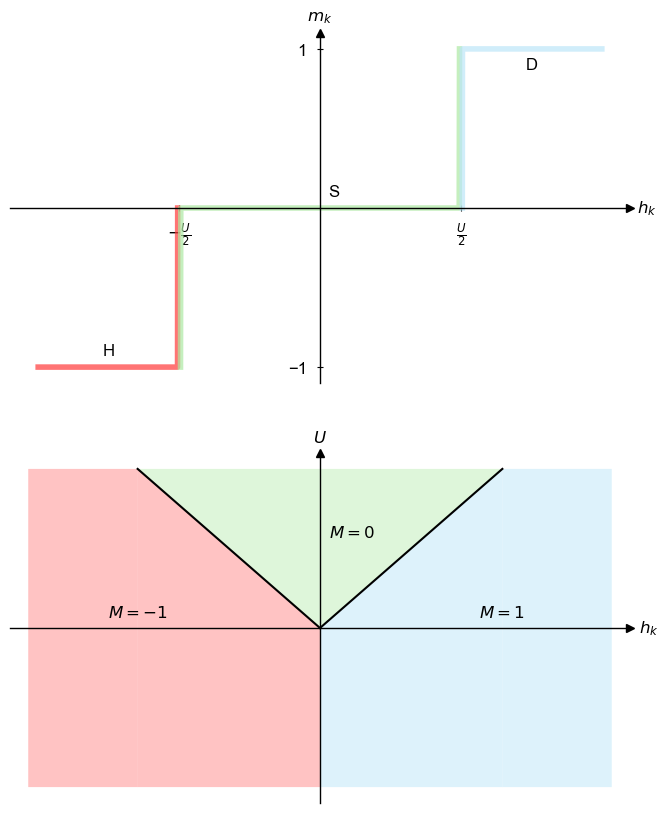

In [155]:
def fig_4_plot_a(ax):
    # Clean up axes
    # Axes styling: x-axis through zero, no y-axis
    ax.spines["bottom"].set_position("zero")
    ax.spines["bottom"].set_color("black")
    ax.spines["bottom"].set_linewidth(1)

    ax.spines["left"].set_position("zero")
    ax.spines["left"].set_color("black")
    ax.spines["left"].set_linewidth(1)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # --- AXIS ARROWS ---
    ax.plot(1, 0, ">k", transform=ax.get_yaxis_transform(), clip_on=False)
    ax.plot(0, 1, "^k", transform=ax.get_xaxis_transform(), clip_on=False)

    ax.text(0, 1.15, r"$m_k$", ha="center", va="bottom")
    ax.text(2.25, 0, r"$h_k$", ha="left", va="center")

    npoints = 1000

    x_H = np.linspace(-2, -1.01, npoints)
    x_S = np.linspace(-0.99, 0.99, npoints)
    x_D = np.linspace(1.01, 2, npoints)

    y_H = np.zeros_like(x_H)
    y_S = np.zeros_like(x_S)
    y_D = np.zeros_like(x_D)

    y_H -= 1
    y_D += 1

    y_H[-1] = 0
    y_S[0] = -1
    y_S[-1] = 1
    y_D[0] = 0
    
    ax.plot(x_H, y_H, color=hole_color, alpha=0.7, linewidth=4)
    ax.plot(x_S, y_S, color=single_color, alpha=0.7, linewidth=4)
    ax.plot(x_D, y_D, color=double_color, alpha=0.7, linewidth=4)

    ax.set_yticks([-1, 1])
    ax.set_xticks([-1, 1])
    ax.set_xticklabels([r"$-\frac{U}{2}$", r"$\frac{U}{2}$"])
    ax.tick_params(direction='inout', pad=7, length=5)

    ax.text(-1.5, -0.9, "H", va="center", ha="center")
    ax.text(0.1, 0.1, "S", va="center", ha="center")
    ax.text(1.5, 0.9, "D", va="center", ha="center")

def fig_4_plot_b(ax, xminmax=1.7):
    npoints = 1000
    x_neg = np.linspace(-1, 0, npoints)
    x_pos = np.linspace(0, 1, npoints)
    y_neg = -x_neg
    y_pos = x_pos

    ax.set_xlim(-xminmax, xminmax)
    ax.set_ylim(-1.1, 1.1)

    # Clean up axes
    # Axes styling: x-axis through zero, no y-axis
    ax.spines["bottom"].set_position("zero")
    ax.spines["bottom"].set_color("black")
    ax.spines["bottom"].set_linewidth(1)

    ax.spines["left"].set_position("zero")
    ax.spines["left"].set_color("black")
    ax.spines["left"].set_linewidth(1)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # --- AXIS ARROWS ---
    ax.plot(1, 0, ">k", transform=ax.get_yaxis_transform(), clip_on=False)
    ax.plot(0, 1, "^k", transform=ax.get_xaxis_transform(), clip_on=False)

    ax.text(0, 1.15, r"$U$", ha="center", va="bottom")
    ax.text(1.75, 0, r"$h_k$", ha="left", va="center")

    ax.set_xticks([])
    ax.set_yticks([])

    ax.plot(x_neg, y_neg, color="black")
    ax.plot(x_pos, y_pos, color="black")

    x_fill_neg = np.linspace(-xminmax + 0.1, -1, npoints)
    x_fill_pos = np.linspace(1, xminmax -0.1, npoints)

    ax.fill_between(x_fill_neg, 1, -1, facecolor=hole_color, alpha=hole_alpha)
    ax.fill_between(x_neg, y_neg, -1, facecolor=hole_color, alpha=hole_alpha)

    ax.fill_between(x_fill_pos, 1, -1, facecolor=double_color, alpha=double_alpha)
    ax.fill_between(x_pos, y_pos, -1, facecolor=double_color, alpha=double_alpha)


    ax.fill_between(x_neg, y_neg, 1, facecolor=single_color, alpha=single_alpha)
    ax.fill_between(x_pos, y_pos, 1, facecolor=single_color, alpha=single_alpha)

    ax.text(-1, 0.1, r"$M=-1$", ha="center", va="center")
    ax.text(1, 0.1, r"$M=1$", ha="center", va="center")
    ax.text(0.05, 0.6, r"$M=0$", ha="left", va="center")




    

fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(8, 10))

axes_flat = axes.flatten()
fig_4_plot_a(axes_flat[0])
fig_4_plot_b(axes_flat[1])

# Figure 5

In [176]:
h_k_color = "brown"

def fig_5_plot_a(ax):
    # Clean up axes
    # Axes styling: x-axis through zero, no y-axis
    ax.spines["bottom"].set_position("zero")
    ax.spines["bottom"].set_color("black")
    ax.spines["bottom"].set_linewidth(1)

    ax.spines["left"].set_position("zero")
    ax.spines["left"].set_color("black")
    ax.spines["left"].set_linewidth(1)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # --- AXIS ARROWS ---
    ax.plot(1, 0, ">k", transform=ax.get_yaxis_transform(), clip_on=False)
    ax.plot(0, 1, "^k", transform=ax.get_xaxis_transform(), clip_on=False)

    ax.text(0, 1.15, r"$m_k$", ha="center", va="bottom")
    ax.text(2.25, 0, r"$h_k$", ha="left", va="center")

    npoints = 10000

    x_H = np.linspace(-2, -1.25, npoints)
    x_S = np.linspace(-0.75, 0.75, npoints)
    x_D = np.linspace(1.25, 2, npoints)

    x_bridge_neg = np.linspace(-1.25, -0.75, npoints)
    x_bridge_pos = np.linspace(0.75, 1.25, npoints)

    y_H = np.zeros_like(x_H)
    y_S = np.zeros_like(x_S)
    y_D = np.zeros_like(x_D)

    y_bridge_neg = np.linspace(-1, 0, npoints)
    y_bridge_pos = np.linspace(0, 1, npoints)

    y_H -= 1
    y_D += 1
    
    ax.plot(x_H, y_H, color=hole_color, alpha=hole_alpha, linewidth=3)
    ax.plot(x_S, y_S, color=single_color, alpha=single_alpha, linewidth=3)
    ax.plot(x_D, y_D, color=double_color, alpha=double_alpha, linewidth=3)

    ax.plot(x_bridge_neg, y_bridge_neg, color=h_k_color)
    ax.plot(x_bridge_pos, y_bridge_pos, color=h_k_color)

    ax.set_xticks([-1.25, -0.75, 0.75, 1.25])
    ax.set_yticks([-1, 1])
    ax.set_xticklabels([r"$-h_2$", r"$-h_1$", r"$h_1$", r"$h_2$"])
    ax.tick_params(direction='inout', pad=7, length=5)

    ax.text(-1.5, -0.9, "H", va="center", ha="center")
    ax.text(0.1, 0.1, "S", va="center", ha="center")
    ax.text(1.5, 0.9, "D", va="center", ha="center")



def fig_5_plot_b(ax):
    npoints = 100
    x2neg = np.linspace(-3, -2.5, npoints)
    x1neg = np.linspace(-2, -1.5, npoints)
    x1pos = np.linspace(1.5, 2, npoints)
    x2pos = np.linspace(2.5, 3, npoints)
    
    yneg = np.linspace(1, 0, npoints)
    ypos = np.linspace(0, 1, npoints)

    # Clean up axes
    # Axes styling: x-axis through zero, no y-axis
    ax.spines["bottom"].set_position("zero")
    ax.spines["bottom"].set_color("black")
    ax.spines["bottom"].set_linewidth(1)

    ax.spines["left"].set_position("zero")
    ax.spines["left"].set_color("black")
    ax.spines["left"].set_linewidth(1)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.set_xlim(-4, 4)

    # --- AXIS ARROWS ---
    ax.plot(1, 0, ">k", transform=ax.get_yaxis_transform(), clip_on=False)
    ax.plot(0, 1, "^k", transform=ax.get_xaxis_transform(), clip_on=False)

    ax.text(0, 1.08, r"$U$", ha="center", va="bottom")
    ax.text(4.1, 0, r"$h_k$", ha="left", va="center")

    ax.set_xticks([-2.5, -1.5, 1.5, 2.5])
    ax.set_yticks([])
    ax.set_xticklabels([r"$-h_2$", r"$-h_1$", r"$h_1$", r"$h_2$"])

    ax.plot(x1neg, yneg, color=h_k_color)
    ax.plot(x2neg, yneg, color=h_k_color)
    ax.plot(x1pos, ypos, color=h_k_color)
    ax.plot(x2pos, ypos, color=h_k_color)

    ax.text(-3.5, 0.25, r"$M=-1$", ha="center", va="center")
    ax.text(3.5, 0.25, r"$M=1$", ha="center", va="center")
    ax.text(0.5, 0.5, r"$M=0$", ha="center", va="center")
    ax.text(2.25, 0.5, r"$0<M<1$", ha="center", va="center", rotation=80)
    ax.text(-2.25, 0.5, r"$-1<M<0$", ha="center", va="center", rotation=-80)

    ax.fill_between(np.linspace(-2.5, -3, npoints, endpoint=False), np.linspace(0, 1, npoints), 
                    color=hole_color, alpha=hole_alpha, linewidth=0, edgecolor='none')
    ax.fill_between([-4, -3], 1, color=hole_color, alpha=hole_alpha, linewidth=0, edgecolor='none')

    ax.fill_between(x1neg, yneg, 1, color=single_color, alpha=single_alpha, linewidth=0, edgecolor='none')
    ax.fill_between(x1pos, ypos, 1, color=single_color, alpha=single_alpha, linewidth=0, edgecolor='none')
    ax.fill_between([-1.5, 1.5], 0, 1, color=single_color, alpha=single_alpha, linewidth=0, edgecolor='none')

    ax.fill_between(x2pos, ypos, 0, color=double_color, alpha=double_alpha, linewidth=0, edgecolor='none')
    ax.fill_between([4, 3], 0, 1, color=double_color, alpha=double_alpha, linewidth=0, edgecolor='none')



def fig_5_plot_c(ax):
    # Clean up axes
    # Axes styling: x-axis through zero, no y-axis
    ax.spines["bottom"].set_position("zero")
    ax.spines["bottom"].set_color("black")
    ax.spines["bottom"].set_linewidth(1)

    ax.spines["left"].set_position("zero")
    ax.spines["left"].set_color("black")
    ax.spines["left"].set_linewidth(1)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # --- AXIS ARROWS ---
    ax.plot(1, 0, ">k", transform=ax.get_yaxis_transform(), clip_on=False)
    ax.plot(0, 1, "^k", transform=ax.get_xaxis_transform(), clip_on=False)

    ax.text(0, 1.45, r"$b_k$", ha="center", va="bottom")
    ax.text(2.25, 0, r"$h_k$", ha="left", va="center")

    npoints = 1000

    x_H = np.linspace(-2, -1.25, npoints)
    x_S = np.linspace(-0.75, 0.75, npoints)
    x_D = np.linspace(1.25, 2, npoints)

    y_H = np.linspace(-1.25, -0.75, npoints)
    y_D = np.linspace(0.75, 1.25, npoints)
    y_S = np.linspace(-0.75, 0.75, npoints)

    x_bridge_neg = np.linspace(-1.25, -0.75, npoints)
    x_bridge_pos = np.linspace(0.75, 1.25, npoints)

    y_bridge_neg = np.zeros_like(x_bridge_neg)
    y_bridge_pos = np.zeros_like(x_bridge_pos)

    y_bridge_neg -= 0.75
    y_bridge_pos += 0.75
    
    ax.plot(x_H, y_H, color=hole_color, alpha=hole_alpha, linewidth=3)
    ax.plot(x_S, y_S, color=single_color, alpha=single_alpha, linewidth=3)
    ax.plot(x_D, y_D, color=double_color, alpha=double_alpha, linewidth=3)

    ax.plot(x_bridge_neg, y_bridge_neg, color=h_k_color)
    ax.plot(x_bridge_pos, y_bridge_pos, color=h_k_color)

    ax.set_xticks([-1.25, -0.75, 0.75, 1.25])
    ax.set_yticks([])
    ax.set_xticklabels([r"$-h_2$", r"$-h_1$", r"$h_1$", r"$h_2$"])
    ax.tick_params(direction='inout', pad=7, length=5)

    

    

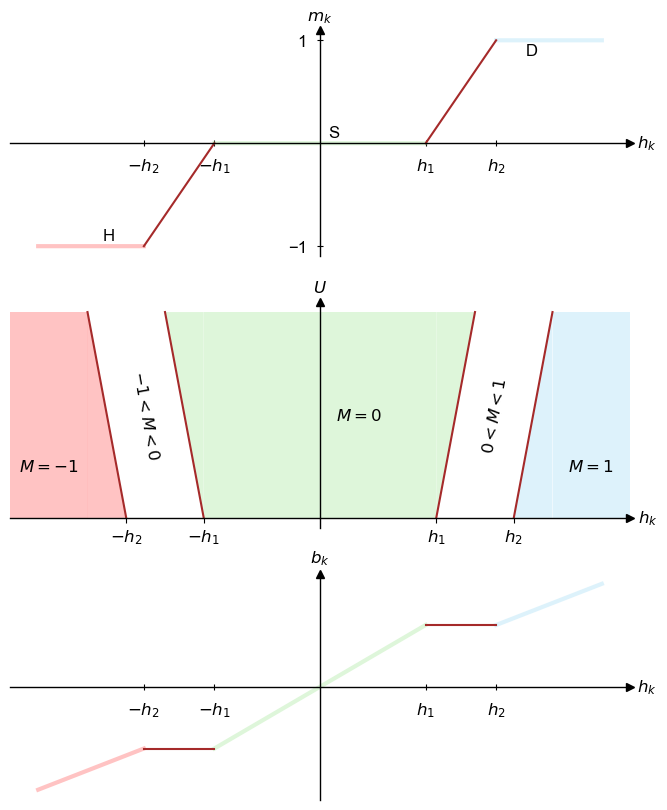

In [177]:
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(8, 10))

axes_flat = axes.flatten()

fig_5_plot_a(axes_flat[0])
fig_5_plot_b(axes_flat[1])
fig_5_plot_c(axes_flat[2])